In [1]:
import sys
import os
import geopandas as gpd
import numpy as np
import rioxarray as rxr
from rasterio import features
from shapely.geometry import shape
from shapely.ops import unary_union
from pyproj import CRS
from pathlib import Path
import rioxarray as rxr
import matplotlib.pyplot as plt
import geopandas as gpd

c:\Users\Clemens\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
species_data = gpd.read_file(Path("data") / "amphibian_subset.shp")

In [3]:
species_names = species_data["sci_name"].unique()

In [4]:
species_data = species_data[species_data["presence"].isin([1,2,3])]
species_data = species_data[species_data["origin"].isin([1,2])]
species_data = species_data[species_data["seasonal"].isin([1,2,3])]

In [5]:
america_bbox = {
    "minx": -170,
    "maxx": -30,
    "miny": -60,
    "maxy": 72
}

species_data = species_data[
    (species_data.geometry.bounds.minx <= america_bbox["maxx"]) &
    (species_data.geometry.bounds.maxx >= america_bbox["minx"]) &
    (species_data.geometry.bounds.miny <= america_bbox["maxy"]) &
    (species_data.geometry.bounds.maxy >= america_bbox["miny"])
]

print("Number of species in America (rough filter):", len(species_data["sci_name"].unique()))

Number of species in America (rough filter): 10


In [6]:
species_data["geometry"] = species_data.geometry.simplify(
    tolerance=0.05,          
    preserve_topology=True
)

species_data = species_data.drop(columns=['id_no', 'presence', 'origin', 'seasonal', 'compiler',
       'yrcompiled', 'citation', 'subspecies', 'subpop', 'source', 'island',
       'tax_comm', 'dist_comm', 'generalisd', 'legend', 'kingdom', 'phylum',
       'class', 'order_', 'family', 'genus', 'category', 'marine',
       'terrestial', 'freshwater', 'SHAPE_Leng', 'SHAPE_Area'])

species_data["geometry"] = species_data.geometry.make_valid()

species_data = species_data.dissolve(by="sci_name").reset_index()

In [7]:
mask = rxr.open_rasterio(
    Path("../../../01_climate_data/01_c_NorESM2/amazon_mask/amazon_mask.tif")
).squeeze()

mask_bool = (mask.values == 1).astype("uint8")

transform = mask.rio.transform()
crs = mask.rio.crs

shapes_gen = features.shapes(mask_bool, transform=transform)


amazon_polygons = [
    shape(geom)
    for geom, value in shapes_gen
    if value == 1
]

amazon_region = unary_union(amazon_polygons)

# Simplify once 
amazon_region = amazon_region.simplify(0.05)

amazon_gdf = gpd.GeoDataFrame(
    geometry=[amazon_region],
    crs=crs
).to_crs("EPSG:4326")

amazon_geom = amazon_gdf.geometry.iloc[0]

In [8]:
results = []

for idx, row in species_data.iterrows():
    species_geom = row.geometry

    if species_geom.is_empty:
        continue

    if not species_geom.intersects(amazon_geom):
        print(f"{row['sci_name']}: ratio = 0.000")
        continue

    # Centroid in lon/lat
    centroid = species_geom.centroid
    lon0, lat0 = centroid.x, centroid.y

    # Local Lambert Azimuthal Equal Area projection
    laea_crs = CRS.from_proj4(
        f"+proj=laea +lat_0={lat0} +lon_0={lon0} "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

    # Reproject species & Amazon
    species_eq = gpd.GeoSeries(
        [species_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).make_valid().iloc[0]

    amazon_eq = gpd.GeoSeries(
        [amazon_geom], crs="EPSG:4326"
    ).to_crs(laea_crs).make_valid().iloc[0]

    species_area = species_eq.area
    if species_area == 0:
        continue

    intersection_area = species_eq.intersection(amazon_eq).area
    ratio = intersection_area / species_area

    print(f"{row['sci_name']}: ratio = {ratio:.3f}")

    if ratio > 0.3:
        results.append({
            "sci_name": row["sci_name"],
            "ratio": ratio,
            "area": species_area / 1e6,   
            "geometry": species_geom      
        })


Allobates fuscellus: ratio = 1.000
Dendropsophus melanargyreus: ratio = 0.570
Dendropsophus schubarti: ratio = 0.999
Leptodactylus wagneri: ratio = 0.999
Lysapsus bolivianus: ratio = 0.843
Osteocephalus buckleyi: ratio = 0.881
Pristimantis diadematus: ratio = 1.000
Rhinella dapsilis: ratio = 1.000
Rhinella margaritifera: ratio = 0.585
Rhinella proboscidea: ratio = 1.000


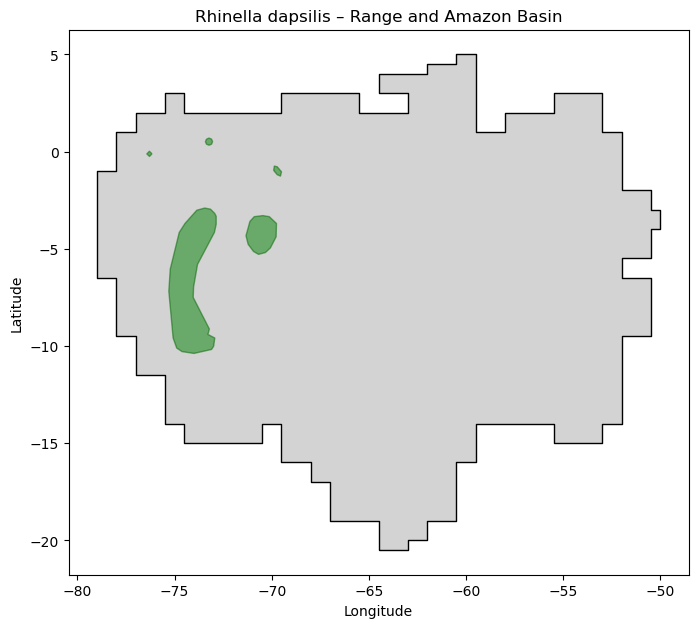

In [9]:
nbr_species_plot = 7
species_geom = results[nbr_species_plot ]["geometry"]
species_to_plot = results[nbr_species_plot ]["sci_name"]

fig, ax = plt.subplots(figsize=(8, 8))

# Amazon basin
gpd.GeoSeries(
    [amazon_geom],
    crs=laea_crs
).plot(
    ax=ax,
    color="lightgrey",
    edgecolor="black",
    linewidth=1,
    label="Amazon basin"
)

# Species range
gpd.GeoSeries(
    [species_geom],
    crs=laea_crs
).plot(
    ax=ax,
    color="green",
    alpha=0.5,
    edgecolor="darkgreen",
    linewidth=1,
    label=species_to_plot
)

ax.set_title(f"{species_to_plot} – Range and Amazon Basin")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.show()
